<a href="https://colab.research.google.com/github/oleksandr-holan/deep-learning/blob/master/lab08/lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Prepare data

In [ ]:
!cp /content/drive/MyDrive/deepl/lab08/train.zip /content/train.zip

In [ ]:
!unzip "/content/train.zip" -d "/content"

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dog.5499.jpg  
  inflating: /content/train/dog.55.jpg  
  inflating: /content/train/dog.550.jpg  
  inflating: /content/train/dog.5500.jpg  
  inflating: /content/train/dog.5501.jpg  
  inflating: /content/train/dog.5502.jpg  
  inflating: /content/train/dog.5503.jpg  
  inflating: /content/train/dog.5504.jpg  
  inflating: /content/train/dog.5505.jpg  
  inflating: /content/train/dog.5506.jpg  
  inflating: /content/train/dog.5507.jpg  
  inflating: /content/train/dog.5508.jpg  
  inflating: /content/train/dog.5509.jpg  
  inflating: /content/train/dog.551.jpg  
  inflating: /content/train/dog.5510.jpg  
  inflating: /content/train/dog.5511.jpg  
  inflating: /content/train/dog.5512.jpg  
  inflating: /content/train/dog.5513.jpg  
  inflating: /content/train/dog.5514.jpg  
  inflating: /content/train/dog.5515.jpg  
  inflating: /content/train/dog.5516.jpg  
  inflating: /content/train/dog.5517.jpg  
  infla

In [ ]:
!rm -rf /content/processed

In [ ]:
import os
import shutil
import random

print("Початок роботи скрипту...")

original_dataset_dir = '/content/train'
base_dir = '/content/processed'


if not os.path.exists(original_dataset_dir):
    print(f"ПОМИЛКА: Директорія з вихідними даними не знайдена за шляхом: {original_dataset_dir}")
    exit(1)

print("Створення директорій...")

os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)
train_cats_dir = os.path.join(train_dir, 'cats')
os.makedirs(train_cats_dir, exist_ok=True)
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.makedirs(train_dogs_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.makedirs(validation_cats_dir, exist_ok=True)
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.makedirs(validation_dogs_dir, exist_ok=True)

print("Структура папок успішно створена.")

Початок роботи скрипту...
Створення директорій...
Структура папок успішно створена.


In [ ]:
TRAIN_SIZE = 10000
VALIDATION_SIZE = 2500

all_cat_fnames = [f'cat.{i}.jpg' for i in range(12500)]
all_dog_fnames = [f'dog.{i}.jpg' for i in range(12500)]

random.shuffle(all_cat_fnames)
random.shuffle(all_dog_fnames)

def copy_files(file_list, source_dir, dest_dir):
  for fname in file_list:
      src = os.path.join(source_dir, fname)
      dst = os.path.join(dest_dir, fname)
      if os.path.exists(src):
          shutil.copyfile(src, dst)
      else:
          print(f"Попередження: Файл {src} не знайдено, пропущено.")

print(f"Копіювання {TRAIN_SIZE} котів для тренування...")
copy_files(all_cat_fnames[:TRAIN_SIZE], original_dataset_dir, train_cats_dir)
print(f"Копіювання {VALIDATION_SIZE} котів для валідації...")
copy_files(all_cat_fnames[TRAIN_SIZE:TRAIN_SIZE + VALIDATION_SIZE], original_dataset_dir, validation_cats_dir)

print(f"Копіювання {TRAIN_SIZE} собак для тренування...")
copy_files(all_dog_fnames[:TRAIN_SIZE], original_dataset_dir, train_dogs_dir)
print(f"Копіювання {VALIDATION_SIZE} собак для валідації...")
copy_files(all_dog_fnames[TRAIN_SIZE:TRAIN_SIZE + VALIDATION_SIZE], original_dataset_dir, validation_dogs_dir)

print("-" * 30)
print("Підготовка даних завершена успішно!")
print(f"Всього у папці train/cats: {len(os.listdir(train_cats_dir))} файлів")
print(f"Всього у папці train/dogs: {len(os.listdir(train_dogs_dir))} файлів")
print(f"Всього у папці validation/cats: {len(os.listdir(validation_cats_dir))} файлів")
print(f"Всього у папці validation/dogs: {len(os.listdir(validation_dogs_dir))} файлів")

Копіювання 10000 котів для тренування...
Копіювання 2500 котів для валідації...
Копіювання 10000 собак для тренування...
Копіювання 2500 собак для валідації...
------------------------------
Підготовка даних завершена успішно!
Всього у папці train/cats: 10000 файлів
Всього у папці train/dogs: 10000 файлів
Всього у папці validation/cats: 2500 файлів
Всього у папці validation/dogs: 2500 файлів


# VGG16

## Load Model

In [ ]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.trainable = False

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.8))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=2e-5),
              metrics=['acc'])

history = model.fit(
      train_generator,
      steps_per_epoch=50,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=25)

Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - acc: 0.5810 - loss: 0.6815 - val_acc: 0.7540 - val_loss: 0.5366
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - acc: 0.6629 - loss: 0.6242 - val_acc: 0.8020 - val_loss: 0.4820
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - acc: 0.7228 - loss: 0.5422 - val_acc: 0.8300 - val_loss: 0.4278
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - acc: 0.7760 - loss: 0.4919 - val_acc: 0.8460 - val_loss: 0.3818
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - acc: 0.7668 - loss: 0.4903 - val_acc: 0.8380 - val_loss: 0.3918
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - acc: 0.7964 - loss: 0.4482 - val_acc: 0.8480 - val_loss: 0.3693
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - acc: 0.8154 - loss: 0.4179 - val_acc: 0.8400 - val_loss: 0.3634
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - acc: 0.8073 - loss: 0.4306 - val_

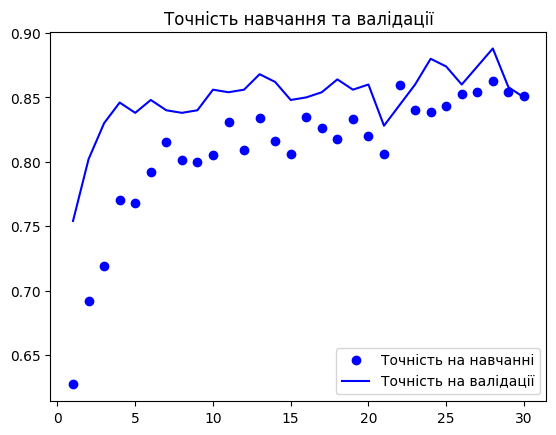

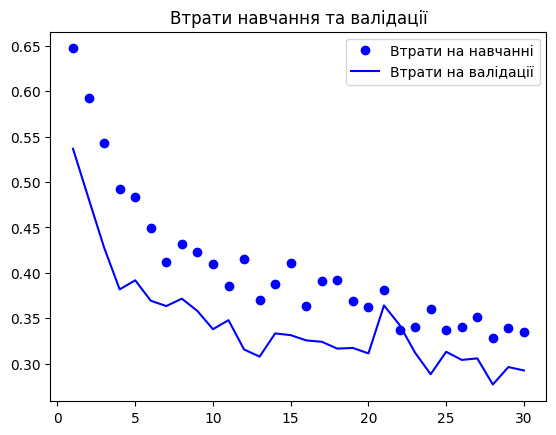

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Точність на навчанні')
plt.plot(epochs, val_acc, 'b', label='Точність на валідації')
plt.title('Точність навчання та валідації')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Втрати на навчанні')
plt.plot(epochs, val_loss, 'b', label='Втрати на валідації')
plt.title('Втрати навчання та валідації')
plt.legend()

plt.show()

In [ ]:
model.save('cats_and_dogs_vgg16.keras')

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (299, 299)
BATCH_SIZE = 16

train_datagen_inception = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen_inception = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_inception = train_datagen_inception.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator_inception = validation_datagen_inception.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

base_model_inception.trainable = False

model_inception = models.Sequential([
    base_model_inception,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_inception.summary()

--- InceptionV3 Full Model Architecture ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,357,729 (211.17 MB)

 Trainable params: 33,554,945 (128.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from tensorflow.keras import optimizers

model_inception.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['acc']
)

history_inception = model_inception.fit(
    train_generator_inception,
    steps_per_epoch=50,
    epochs=15,
    validation_data=validation_generator_inception,
    validation_steps=25,
    callbacks=[lr_scheduler]
)



--- Starting Training for InceptionV3 Model ---
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 541ms/step - acc: 0.8041 - loss: 0.5204 - val_acc: 0.9900 - val_loss: 0.0301 - learning_rate: 1.0000e-05
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 393ms/step - acc: 0.9702 - loss: 0.0752 - val_acc: 0.9825 - val_loss: 0.0419 - learning_rate: 1.0000e-05
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step - acc: 0.9686 - loss: 0.0950 - val_acc: 0.9950 - val_loss: 0.0242 - learning_rate: 1.0000e-05
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - acc: 0.9668 - loss: 0.0910 - val_acc: 0.9875 - val_loss: 0.0546 - learning_rate: 1.0000e-05
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 385ms/step - acc: 0.9577 - loss: 0.1187 - val_acc: 1.0000 - val_loss: 0.0068 - learning_rate: 1.0000e-05
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - acc: 0.9758 - loss: 0.0753 - val_acc: 1.0000 - val_loss: 0.0043 - learning_rate: 1.0000e-05
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 376ms/step - acc: 0.9698 - 

In [ ]:
model_inception.save('cats_vs_dogs_inceptionv3.keras')

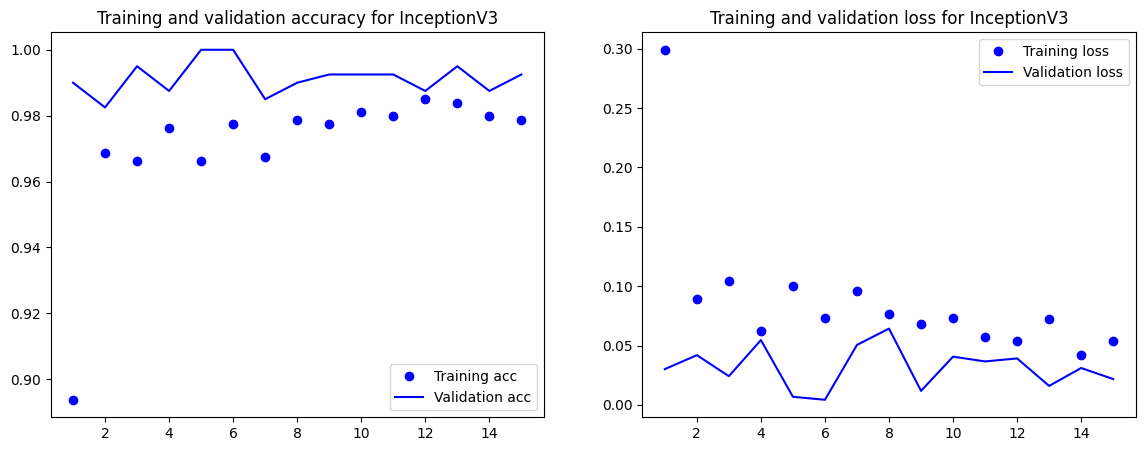

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title(f'Training and validation accuracy for {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title(f'Training and validation loss for {model_name}')
    plt.legend()

    plt.show()

plot_history(history_inception, "InceptionV3")

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_resnet = train_datagen_resnet.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator_resnet = validation_datagen_resnet.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
base_model_resnet.trainable = False

In [ ]:
model_resnet = models.Sequential([
    base_model_resnet,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation='sigmoid')
])

model_resnet.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,278,337 (187.98 MB)

 Trainable params: 25,690,625 (98.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model_resnet.compile(
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['acc']
)

history_resnet = model_resnet.fit(
    train_generator_resnet,
    steps_per_epoch=50,
    epochs=15,
    validation_data=validation_generator_resnet,
    validation_steps=25
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 346ms/step - acc: 0.6991 - loss: 1.2984 - val_acc: 0.9550 - val_loss: 0.1408
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 263ms/step - acc: 0.8592 - loss: 0.6069 - val_acc: 0.9875 - val_loss: 0.0418
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - acc: 0.8802 - loss: 0.4835 - val_acc: 0.9875 - val_loss: 0.0401
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - acc: 0.9002 - loss: 0.3336 - val_acc: 0.9650 - val_loss: 0.1111
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step - acc: 0.9272 - loss: 0.2551 - val_acc: 0.9700 - val_loss: 0.0735
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - acc: 0.9407 - loss: 0.2342 - val_acc: 0.9900 - val_loss: 0.0231
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - acc: 0.9199 - loss: 0.2684 - val_acc: 0.9875 - val_loss: 0.0376
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - acc: 0.9253 - loss: 0.3471 - val_acc: 0.9775 - val_loss: 0.0432
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/

In [ ]:
model_resnet.save('cats_vs_dogs_resnet50.keras')

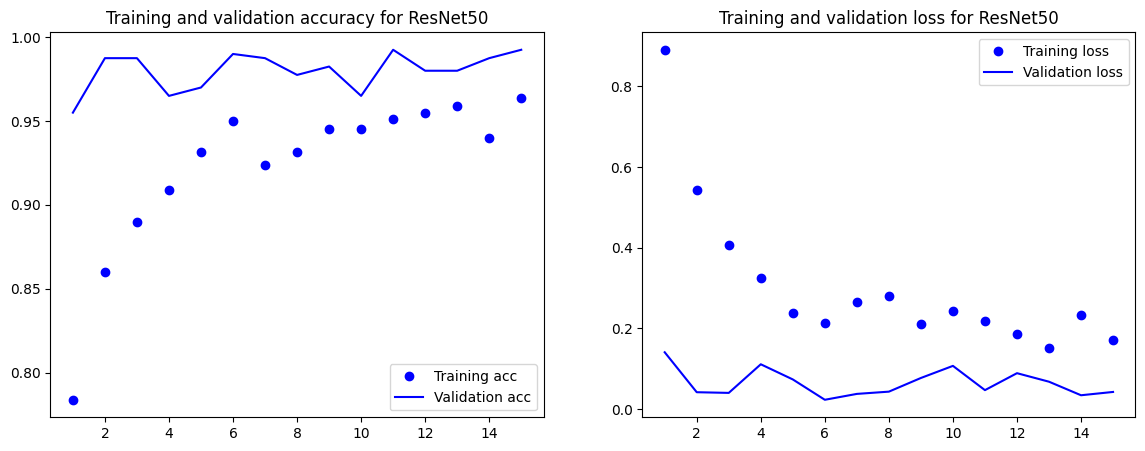

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title(f'Training and validation accuracy for {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title(f'Training and validation loss for {model_name}')
    plt.legend()

    plt.show()

plot_history(history_resnet, "ResNet50")